### 1. Combine all prediction files

Use the probabilities from:

- Logistic Regression
- Random Forest
- XGBoost
- Attention MLP

In [8]:
import pandas as pd

# Load prediction files
df_lr = pd.read_csv("logistic_predictions.csv")
df_rf = pd.read_csv("rf_predictions.csv")
df_xgb = pd.read_csv("xgb_predictions.csv")
df_attn = pd.read_csv("attention_mlp_predictions.csv")

# Build one combined dataset
df_meta = pd.DataFrame({
    "y_true": df_lr["y_true"],
    "lr_proba": df_lr["y_proba"],
    "rf_proba": df_rf["y_proba_rf"],
    "xgb_proba": df_xgb["y_proba_xgb"],
    "attn_proba": df_attn["y_proba_attn"]
})

print(df_meta.head())
print(df_meta.shape)

# Save combined dataset
df_meta.to_csv("ebm_meta_dataset.csv", index=False)
print("Combined meta-dataset saved as ebm_meta_dataset.csv")

   y_true  lr_proba  rf_proba  xgb_proba  attn_proba
0       0  0.359663  0.318531   0.308856    0.320727
1       0  0.491742  0.617431   0.569467    0.598152
2       0  0.404828  0.370989   0.421394    0.452589
3       1  0.309351  0.252245   0.278442    0.252090
4       1  0.367140  0.280757   0.348135    0.250949
(14000, 5)
Combined meta-dataset saved as ebm_meta_dataset.csv


In [9]:
import pandas as pd
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.metrics import (
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    classification_report
)
import numpy as np



# =========================
# CONFIG
# =========================
CONFIG = {
    'ebm_max_bins': 350,
    'ebm_interactions': 40,
    'target_recall': 0.8
}
MAIN_SEED = 42


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

### 2. Separate features and target

Now EBM will use only the model outputs as input features.

In [10]:
X_meta = df_meta[["lr_proba", "rf_proba", "xgb_proba", "attn_proba"]]
y_meta = df_meta["y_true"]

#### 3. Train EBM on this combined dataset

In [11]:
from sklearn.model_selection import train_test_split

X_meta_train, X_meta_test, y_meta_train, y_meta_test = train_test_split(
    X_meta, y_meta,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_meta
)

# Train
ebm_meta.fit(X_meta_train, y_meta_train)



,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,'3x'
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.015
,greedy_ratio,10.0


### Prediction

In [17]:

# Predict
y_meta_test_proba = ebm_meta.predict_proba(X_meta_test)[:, 1]


###  CALIBRATION CURVE

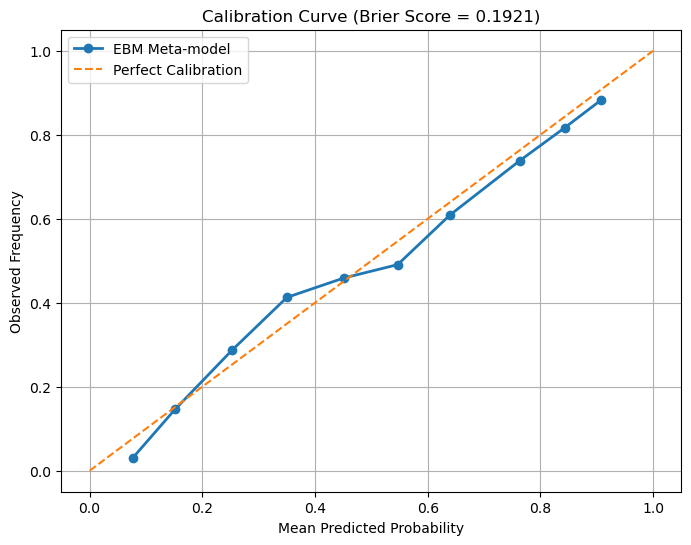

In [45]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(
    y_meta_test,
    y_meta_test_proba,
    n_bins=10,
    strategy="uniform"
)

brier = brier_score_loss(y_meta_test, y_meta_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='EBM Meta-model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title(f"Calibration Curve (Brier Score = {brier:.4f})")
plt.legend()
plt.grid(True)

# SAVE
plt.savefig("calibration_curve_ebm.png", dpi=300, bbox_inches="tight")

plt.show()

#### PROBABILITY DISTRIBUTION

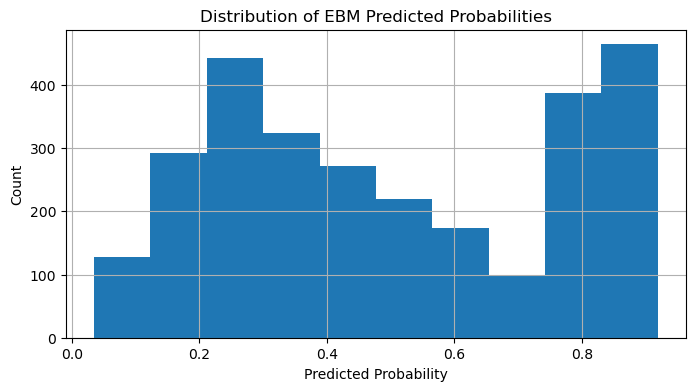

In [44]:
plt.figure(figsize=(8, 4))
plt.hist(y_meta_test_proba, bins=10)

plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Distribution of EBM Predicted Probabilities")
plt.grid(True)

# SAVE
plt.savefig("probability_distribution_ebm.png", dpi=300, bbox_inches="tight")

plt.show()

#### Threshold turning and performance metrice

In [31]:
# Threshold
optimal_threshold = 0.46
y_pred = (y_meta_test_proba >= optimal_threshold).astype(int)

print(f"\nFinal Performance (threshold={optimal_threshold:.4f}):")

print(f"ROC-AUC:   {roc_auc_score(y_meta_test, y_meta_test_proba):.4f}")
print(f"PR-AUC:    {average_precision_score(y_meta_test, y_meta_test_proba):.4f}")
print(f"Accuracy:  {accuracy_score(y_meta_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_meta_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_meta_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_meta_test, y_pred):.4f}")


Final Performance (threshold=0.4600):
ROC-AUC:   0.7769
PR-AUC:    0.7554
Accuracy:  0.7075
F1-Score:  0.7063
Recall:    0.7041
Precision: 0.7086


#### Confusion matrix

In [32]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_meta_test, y_pred).ravel()

print("\nConfusion Matrix:")
print(f"TN (True Negatives):  {tn}")
print(f"FP (False Positives): {fp}")
print(f"FN (False Negatives): {fn}")
print(f"TP (True Positives):  {tp}")


Confusion Matrix:
TN (True Negatives):  996
FP (False Positives): 405
FN (False Negatives): 414
TP (True Positives):  985


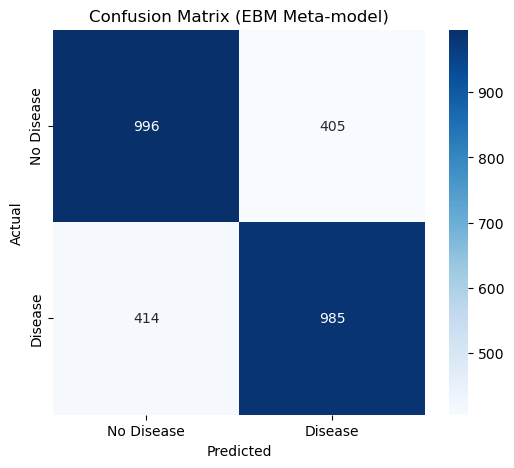

<Figure size 640x480 with 0 Axes>

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_meta_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (EBM Meta-model)")
plt.show()

# SAVE
plt.savefig("confusion_matrix_ebm.png", dpi=300, bbox_inches="tight")

plt.show()

In [37]:
import joblib

joblib.dump(ebm_meta, "ebm_model.pkl")

print("Model saved successfully as ebm_model.pkl")

Model saved successfully as ebm_model.pkl


In [38]:
import joblib

# Load model
ebm_model = joblib.load("ebm_model.pkl")

print("EBM model loaded successfully")

EBM model loaded successfully


In [39]:
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show


ebm_global = ebm_model.explain_global()
show(ebm_global)

C:\Users\Maria\anaconda3\envs\heart-attack-env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


<!-- http://127.0.0.1:7195/2475349611984/ -->